Finalize annotations.

Fix gene names for pushing to pulm-data.

In [1]:
import sys
sys.path.insert(0, '../lib')

In [ ]:
import os
import re
import csv
import scvi
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import anndata as ad
import pynndescent
import numba
import seaborn as sns
import sc_utils
import gc
import shutil
import rapids_singlecell as rsc

import common_data

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scvi/_settings.py:63: UserWarning: Since v1.0.0, scvi-tools no longer uses a random seed by default. Run `scvi.settings.seed = 0` to reproduce results from previous versions.
  self.seed = seed
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scvi/_settings.py:70: UserWarning: Setting `dl_pin_memory_gpu_training` is deprecated in v1.0 and will be removed in v1.1. Please pass in `pin_memory` to the data loaders instead.
  self.dl_pin_memory_gpu_training = (


In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 300)

## Load object

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / '08_rc1_full/08_rc1_full.h5ad')

## Fix gene names

### Remove "GRCh38______" prefix from gene names

In [3]:
adata.var.gene_ids = [i.split('GRCh38______')[1] if i.startswith('GRCh38______') else i for i in adata.var.gene_ids]

In [4]:
adata.var.tail(5)

,gene_ids,feature_types,genome,mito,ribo,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells,means,variances,residual_variances,highly_variable_rank,highly_variable_nbatches,highly_variable_intersection,highly_variable
MT-ND4,ENSG00000198886,Gene Expression,GRCh38,True,False,2841304,13.489193,5.998295,40725876.0,2841304,13.507647,273.622570,24.552659,28.0,304,True,True
MT-ND5,ENSG00000198786,Gene Expression,GRCh38,True,False,2765869,8.750227,8.493986,26421076.0,2765869,8.762767,114.642266,17.920989,48.0,303,False,True
MT-ND6,ENSG00000198695,Gene Expression,GRCh38,True,False,1621107,1.574516,46.367294,4759145.0,1621107,1.576743,7.884218,7.647397,145.0,299,False,True
MT-CYB,ENSG00000198727,Gene Expression,GRCh38,True,False,2929115,22.617147,3.093156,68315296.0,2929115,22.650265,836.029974,42.744954,11.0,304,True,True
AC233755.1,ENSG00000275063,Gene Expression,GRCh38,False,False,11563,0.500670,99.617450,1513329.0,11563,0.498434,1295.826601,4.098969,209.5,98,False,True


In [5]:
adata

AnnData object with n_obs × n_vars = 2452841 × 1000
    obs: 'name', 'library_id', 'individual', 'protocol', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'pct_counts_ribo', 'n_counts', '_scvi_batch', '_scvi_labels', 'cell_type', 'ICU_stay', 'ICU_day', 'Episode_id', 'bal_barcode', 'Binary_outcome', 'Discharge_disposition', 'Episode_etiology', 'Immunocompromised_flag', 'External_transfer_flag', 'SOFA_score', 'viral_pathogen', 'pathogen_groups', 'clear_cut', 'number_of_pathogens', 'episode_type', 'clinical_opinion_l2', 'day_of_hospitalization', 'week_of_hospitalization', 'episode_counter', 'future_episode_outcome', 'is_episode_cured', 'future_vap_onset', 'vap_onset', 'number_of_bals', 'number_of_episodes', 'total_pathogens', 'number_of_total_pathogens', 'prev_episode_type', 'first_episode_type', 'first_pathogen', 'prev_pathogen_groups', 'neutrophils', 'cohort', 'patient', 'is_h

## Resolve proliferating CD8 cells within CD4 cluster

In [6]:
cd4 = adata[adata.obs.cell_type.isin(['CD4 T cells'])]

In [7]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(cd4, use_rep="X_scVI")
rsc.tl.umap(cd4, min_dist=0.3)

In [8]:
# neighbors were already computed using scVI
rsc.tl.leiden(cd4, key_added="cell_type", resolution=0.1)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


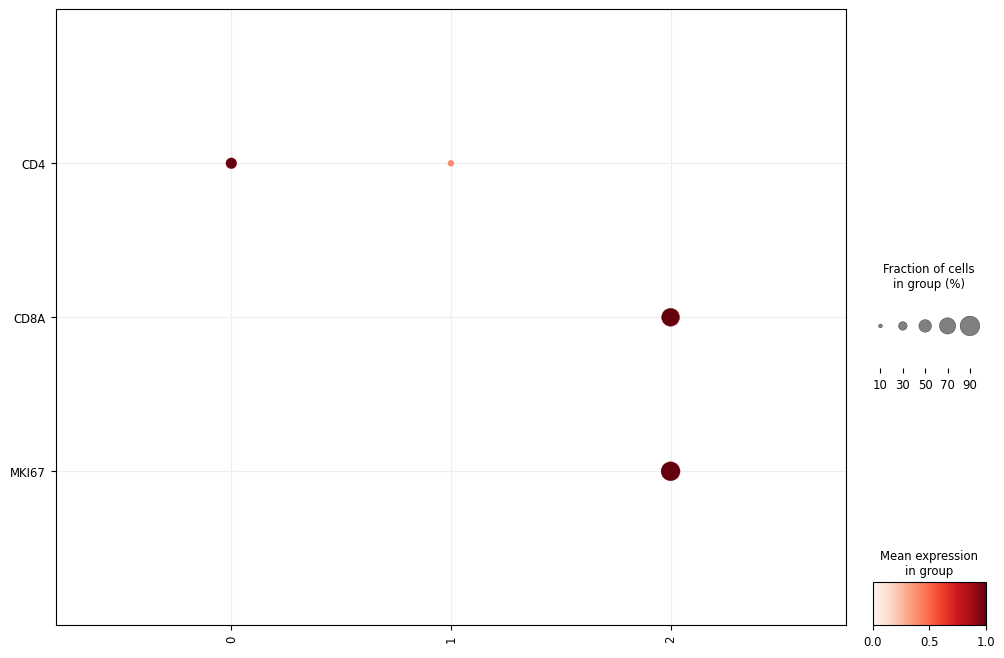

In [9]:
ax = sc.pl.dotplot(
    cd4,
    ["CD4","CD8A","MKI67"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

In [10]:
cd4.obs.cell_type.replace({
    "0": "CD4 T cells",
    "1": "CD4 T cells",
    "2": "Proliferating CD8 T cells",
}, inplace=True)

## Resolve non-proliferating plasma cells within "proliferating plasma cells" cluster

In [11]:
plasma = adata[adata.obs.cell_type.isin(['Proliferating plasma cells'])]

In [12]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(plasma, use_rep="X_scVI")
rsc.tl.umap(plasma, min_dist=0.3)

In [13]:
# neighbors were already computed using scVI
rsc.tl.leiden(plasma, key_added="cell_type", resolution=0.1)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


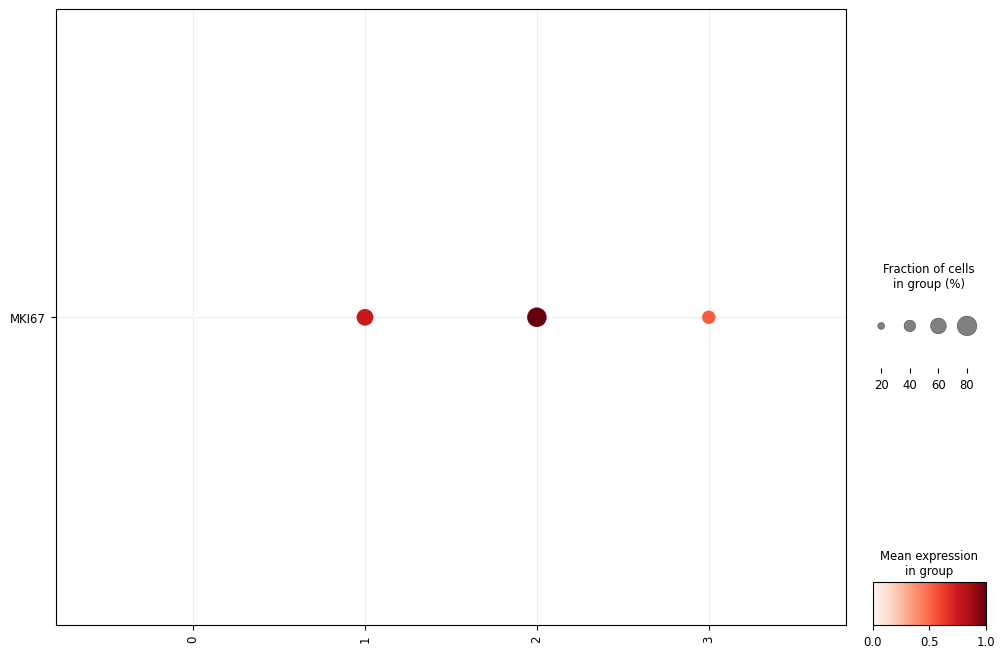

In [14]:
ax = sc.pl.dotplot(
    plasma,
    ["MKI67"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

In [15]:
plasma.obs.cell_type.replace({
    "0": "Plasma cells",
    "1": "Proliferating plasma cells",
    "2": "Proliferating plasma cells",
    "3": "Proliferating plasma cells",
}, inplace=True)

## Recluster Monocytes-1 to resolve “Classical Monocytes-1” (FCN1+FCGR3A-) and “Non-classical monocytes” (FCN1+FCGR3A+)

In [16]:
monocytes = adata[adata.obs.cell_type.isin(['Monocytes-1'])]

In [17]:
# use scVI latent space for UMAP generation
sc.pp.neighbors(monocytes, use_rep="X_scVI")
rsc.tl.umap(monocytes, min_dist=0.3)

In [18]:
# neighbors were already computed using scVI
rsc.tl.leiden(monocytes, key_added="cell_type", resolution=0.2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:748: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


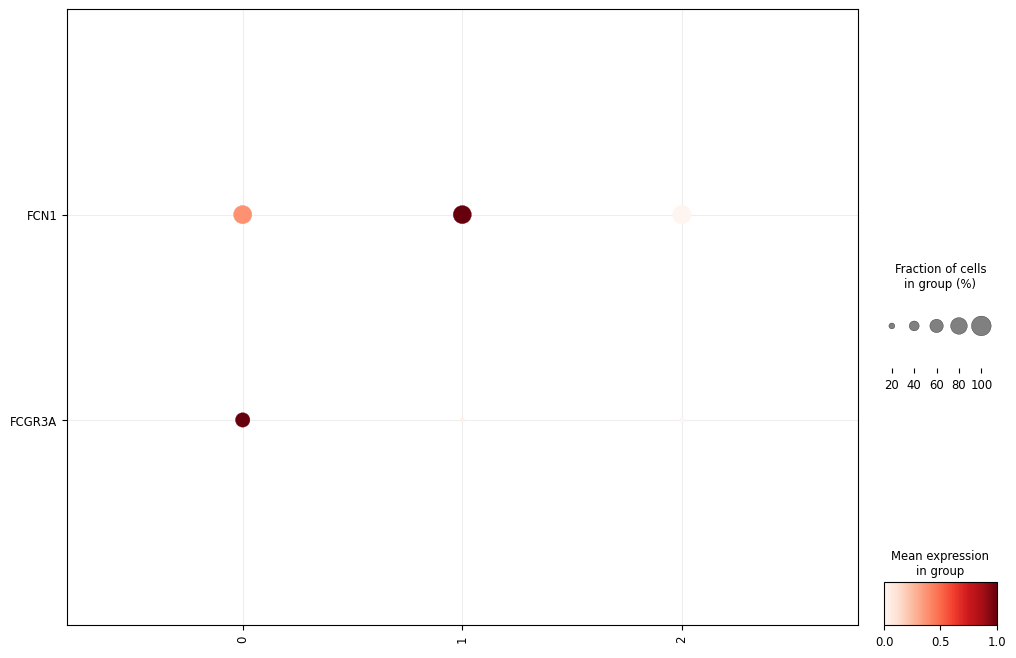

In [19]:
ax = sc.pl.dotplot(
    monocytes,
    ["FCN1","FCGR3A"],
    groupby="cell_type",
    swap_axes=True,
    figsize=(12, 8),
    standard_scale="var",
    edgecolor=None,
    show=False,
    zorder=2,
    use_raw=True
)
ax["mainplot_ax"].grid(c="#eeeeee", zorder=0)

In [20]:
monocytes.obs.cell_type.replace({
    "0": "Non-classical monocytes",
    "1": "Classical Monocytes-1",
    "2": "Classical Monocytes-1",
}, inplace=True)

## Add new cluster labels into large adata object

In [21]:
adata.obs.cell_type = adata.obs.cell_type.astype("str")

In [22]:
adata.obs.loc[cd4.obs_names, "cell_type"] = cd4.obs.cell_type

In [23]:
adata.obs.loc[plasma.obs_names, "cell_type"] = plasma.obs.cell_type

In [24]:
adata.obs.loc[monocytes.obs_names, "cell_type"] = monocytes.obs.cell_type

## Final annotations! Hierarchical labels from Sasha

In [25]:
adata.obs.cell_type.unique().tolist()

['CD4 T cells',
 'CD8 T cells',
 'Mast cells',
 'TRAM-1 FABP4',
 'B cells',
 'MoAM-1',
 'DC2',
 'Macrophages',
 'TRAM-3 FABP4',
 'MoAM-3',
 'Proliferating CD4 T cells',
 'MoAM-8',
 'MoAM-2',
 'Proliferating CD8 T cells',
 'Monocytes-2 IL1B',
 'Secretory cells',
 'Proliferating macrophages',
 'Tregs',
 'MoAM-7',
 'TRAM-4 FABP4',
 'MoAM-6',
 'MoAM-5',
 'DC1',
 'SPP1 MoAM',
 'Ionocytes',
 'Ciliated cells',
 'TRAM-2 FABP4',
 'gdT cells',
 'Migratory DC',
 'Perivascular macrophages',
 'Hematopoietic stem cells',
 'Classical Monocytes-1',
 'MoAM-4',
 'pDC',
 'Epithelial cells',
 'Proliferating plasma cells',
 'Non-classical monocytes',
 'Plasma cells',
 'Proliferating CD8 and gdT cells']

### Level 1 annotations

In [26]:
adata.obs['Level_1'] = adata.obs.cell_type.copy()

In [27]:
adata.obs.Level_1.replace({
    "Epithelial cells": "Epithelial",
    "Secretory cells": "Epithelial",
    "Ciliated cells": "Epithelial",
    "Ionocytes": "Epithelial",
    "CD4 T cells": "Immune",
    "Proliferating CD4 T cells": "Immune",
    "Tregs": "Immune",
    "CD8 T cells": "Immune",
    "Proliferating CD8 T cells": "Immune",
    "gdT cells": "Immune",
    "Proliferating CD8 and gdT cells": "Immune",
    "B cells": "Immune",
    "Plasma cells": "Immune",
    "Proliferating plasma cells": "Immune",
    "Hematopoietic stem cells": "Immune",
    "Mast cells": "Immune",
    "pDC": "Immune",
    "DC1": "Immune",
    "DC2": "Immune",
    "Migratory DC": "Immune",
    "Classical Monocytes-1": "Immune",
    "Monocytes-2 IL1B": "Immune",
    "Non-classical monocytes": "Immune",
    "SPP1 MoAM": "Immune",
    "MoAM-2": "Immune",
    "MoAM-3": "Immune",
    "MoAM-5": "Immune",
    "MoAM-6": "Immune",
    "MoAM-1": "Immune",
    "MoAM-7": "Immune",
    "MoAM-8": "Immune",
    "Macrophages": "Immune",
    "MoAM-4": "Immune",
    "TRAM-3 FABP4": "Immune",
    "TRAM-1 FABP4": "Immune",
    "TRAM-2 FABP4": "Immune",
    "TRAM-4 FABP4": "Immune",
    "Proliferating macrophages": "Immune",
    "Perivascular macrophages": "Immune",
}, inplace=True)

### Level 2 annotations

In [28]:
adata.obs['Level_2'] = adata.obs.cell_type.copy()

In [29]:
adata.obs.Level_2.replace({
    "Epithelial cells": "Epithelial cells",
    "Secretory cells": "Epithelial cells",
    "Ciliated cells": "Epithelial cells",
    "Ionocytes": "Epithelial cells",
    "CD4 T cells": "T cells",
    "Proliferating CD4 T cells": "T cells",
    "Tregs": "T cells",
    "CD8 T cells": "T cells",
    "Proliferating CD8 T cells": "T cells",
    "gdT cells": "T cells",
    "Proliferating CD8 and gdT cells": "T cells",
    "B cells": "B cells",
    "Plasma cells": "B cells",
    "Proliferating plasma cells": "B cells",
    "Hematopoietic stem cells": "Hematopoietic stem cells",
    "Mast cells": "Mast cells",
    "pDC": "Dendritic cells",
    "DC1": "Dendritic cells",
    "DC2": "Dendritic cells",
    "Migratory DC": "Dendritic cells",
    "Classical Monocytes-1": "M&Ms",
    "Monocytes-2 IL1B": "M&Ms",
    "Non-classical monocytes": "M&Ms",
    "SPP1 MoAM": "M&Ms",
    "MoAM-2": "M&Ms",
    "MoAM-3": "M&Ms",
    "MoAM-5": "M&Ms",
    "MoAM-6": "M&Ms",
    "MoAM-1": "M&Ms",
    "MoAM-7": "M&Ms",
    "MoAM-8": "M&Ms",
    "Macrophages": "M&Ms",
    "MoAM-4": "M&Ms",
    "TRAM-3 FABP4": "M&Ms",
    "TRAM-1 FABP4": "M&Ms",
    "TRAM-2 FABP4": "M&Ms",
    "TRAM-4 FABP4": "M&Ms",
    "Proliferating macrophages": "M&Ms",
    "Perivascular macrophages": "M&Ms",
}, inplace=True)

### Level 3 annotations

In [30]:
adata.obs['Level_3'] = adata.obs.cell_type.copy()

In [31]:
adata.obs.Level_3.replace({
    "Epithelial cells": "AT1 and AT2",
    "Secretory cells": "Secretory cells",
    "Ciliated cells": "Ciliated cells",
    "Ionocytes": "Ionocytes",
    "CD4 T cells": "CD4 T cells",
    "Proliferating CD4 T cells": "CD4 T cells",
    "Tregs": "Tregs",
    "CD8 T cells": "CD8 T cells",
    "Proliferating CD8 T cells": "CD8 T cells",
    "gdT cells": "gdT cells",
    "Proliferating CD8 and gdT cells": "gdT cells",
    "B cells": "B cells",
    "Plasma cells": "Plasma cells",
    "Proliferating plasma cells": "Plasma cells",
    "Hematopoietic stem cells": "Hematopoietic stem cells",
    "Mast cells": "Mast cells",
    "pDC": "pDC",
    "DC1": "DC1",
    "DC2": "DC2",
    "Migratory DC": "Migratory DC",
    "Classical Monocytes-1": "Monocytes",
    "Monocytes-2 IL1B": "Monocytes",
    "Non-classical monocytes": "Monocytes",
    "SPP1 MoAM": "MRC1+ Macs",
    "MoAM-2": "MRC1+ Macs",
    "MoAM-3": "MRC1+ Macs",
    "MoAM-5": "MRC1+ Macs",
    "MoAM-6": "MRC1+ Macs",
    "MoAM-1": "MRC1+ Macs",
    "MoAM-7": "MRC1+ Macs",
    "MoAM-8": "MRC1+ Macs",
    "Macrophages": "MRC1+ Macs",
    "MoAM-4": "NUPR1+ Macs",
    "TRAM-3 FABP4": "NUPR1+ Macs",
    "TRAM-1 FABP4": "NUPR1+ Macs",
    "TRAM-2 FABP4": "NUPR1+ Macs",
    "TRAM-4 FABP4": "NUPR1+ Macs",
    "Proliferating macrophages": "NUPR1+ Macs",
    "Perivascular macrophages": "Perivascular macrophages",
}, inplace=True)

### Level 4 annotations

In [32]:
adata.obs['Level_4'] = adata.obs.cell_type.copy()

In [33]:
adata.obs.Level_4.replace({
    "Epithelial cells": "AT1 and AT2",
    "Secretory cells": "Secretory cells",
    "Ciliated cells": "Ciliated cells",
    "Ionocytes": "Ionocytes",
    "CD4 T cells": "CD4 T cells",
    "Proliferating CD4 T cells": "Proliferating CD4 T cells",
    "Tregs": "Tregs",
    "CD8 T cells": "CD8 T cells",
    "Proliferating CD8 T cells": "Proliferating CD8 T cells",
    "gdT cells": "gdT cells",
    "Proliferating CD8 and gdT cells": "Proliferating gdT cells",
    "B cells": "B cells",
    "Plasma cells": "Plasma cells",
    "Proliferating plasma cells": "Proliferating plasma cells",
    "Hematopoietic stem cells": "Hematopoietic stem cells",
    "Mast cells": "Mast cells",
    "pDC": "pDC",
    "DC1": "DC1",
    "DC2": "DC2",
    "Migratory DC": "Migratory DC",
    "Classical Monocytes-1": "Classical monocytes-1 CCR2",
    "Monocytes-2 IL1B": "Classical monocytes-2 IL1B",
    "Non-classical monocytes": "Non-classical monocytes",
    "SPP1 MoAM": "MRC1+C1QA-",
    "MoAM-2": "MRC1+C1QA-",
    "MoAM-3": "MRC1+C1QA-",
    "MoAM-5": "MRC1+C1QA-",
    "MoAM-6": "MRC1+C1QA-",
    "MoAM-1": "MRC1+C1QA+",
    "MoAM-7": "MRC1+C1QA+",
    "MoAM-8": "MRC1+C1QA+",
    "Macrophages": "MRC1+C1QA+",
    "MoAM-4": "NUPR1+FABP4- Macs",
    "TRAM-3 FABP4": "NUPR1+FABP4- Macs",
    "TRAM-1 FABP4": "NUPR1+FABP4+ Macs",
    "TRAM-2 FABP4": "NUPR1+FABP4+ Macs",
    "TRAM-4 FABP4": "NUPR1+FABP4+ Macs",
    "Proliferating macrophages": "NUPR1+FABP4+ Macs",
    "Perivascular macrophages": "Perivascular macrophages",
}, inplace=True)

### Level 5 annotations

In [34]:
adata.obs['Level_5'] = adata.obs.cell_type.copy()

In [35]:
adata.obs.Level_5.replace({
    "Epithelial cells": "AT1 and AT2",
    "Secretory cells": "Secretory cells",
    "Ciliated cells": "Ciliated cells",
    "Ionocytes": "Ionocytes",
    "CD4 T cells": "CD4 T cells",
    "Proliferating CD4 T cells": "Proliferating CD4 T cells",
    "Tregs": "Tregs",
    "CD8 T cells": "CD8 T cells",
    "Proliferating CD8 T cells": "Proliferating CD8 T cells",
    "gdT cells": "gdT cells",
    "Proliferating CD8 and gdT cells": "Proliferating gdT cells",
    "B cells": "B cells",
    "Plasma cells": "Plasma cells",
    "Proliferating plasma cells": "Proliferating plasma cells",
    "Hematopoietic stem cells": "Hematopoietic stem cells",
    "Mast cells": "Mast cells",
    "pDC": "pDC",
    "DC1": "DC1",
    "DC2": "DC2",
    "Migratory DC": "Migratory DC",
    "Classical Monocytes-1": "Classical monocytes-1 CCR2",
    "Monocytes-2 IL1B": "Classical monocytes-2 IL1B",
    "Non-classical monocytes": "Non-classical monocytes",
    "SPP1 MoAM": "MRC1+C1QA- Mac-1",
    "MoAM-2": "MRC1+C1QA- Mac-2",
    "MoAM-3": "MRC1+C1QA- Mac-3",
    "MoAM-5": "MRC1+C1QA- Mac-4",
    "MoAM-6": "MRC1+C1QA- Mac-5",
    "MoAM-1": "MRC1+C1QA+ Mac-6",
    "MoAM-7": "MRC1+C1QA+ Mac-7",
    "MoAM-8": "MRC1+C1QA+ Mac-8",
    "Macrophages": "MRC1+C1QA+ Mac-9",
    "MoAM-4": "NUPR1+FABP4- Mac-10",
    "TRAM-3 FABP4": "NUPR1+FABP4- Mac-11",
    "TRAM-1 FABP4": "NUPR1+FABP4+ Mac-12",
    "TRAM-2 FABP4": "NUPR1+FABP4+ Mac-13",
    "TRAM-4 FABP4": "NUPR1+FABP4+ Mac-14",
    "Proliferating macrophages": "Proliferating macrophages",
    "Perivascular macrophages": "Perivascular macrophages",
}, inplace=True)

### Level 6 annotations

In [36]:
adata.obs['Level_6'] = adata.obs.Level_5.copy()

In [37]:
adata.obs.Level_6.replace({
    "MRC1+C1QA- Mac-1": "MRC1+C1QA-",
    "MRC1+C1QA- Mac-2": "MRC1+C1QA-",
    "MRC1+C1QA- Mac-3": "MRC1+C1QA-",
    "MRC1+C1QA- Mac-4": "MRC1+C1QA-",
    "MRC1+C1QA- Mac-5": "MRC1+C1QA-",
    "MRC1+C1QA+ Mac-6": "MRC1+C1QA+",
    "MRC1+C1QA+ Mac-7": "MRC1+C1QA+",
    "MRC1+C1QA+ Mac-8": "MRC1+C1QA+",
    "MRC1+C1QA+ Mac-9": "MRC1+C1QA+",
    "NUPR1+FABP4- Mac-10": "NUPR1+ Macs",
    "NUPR1+FABP4- Mac-11": "NUPR1+ Macs",
    "NUPR1+FABP4+ Mac-12": "NUPR1+ Macs",
    "NUPR1+FABP4+ Mac-13": "NUPR1+ Macs",
    "NUPR1+FABP4+ Mac-14": "NUPR1+ Macs",
    "Proliferating macrophages": "Proliferating NUPR1+ Macs",
}, inplace=True)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'Level_1'}, xlabel='UMAP1', ylabel='UMAP2'>

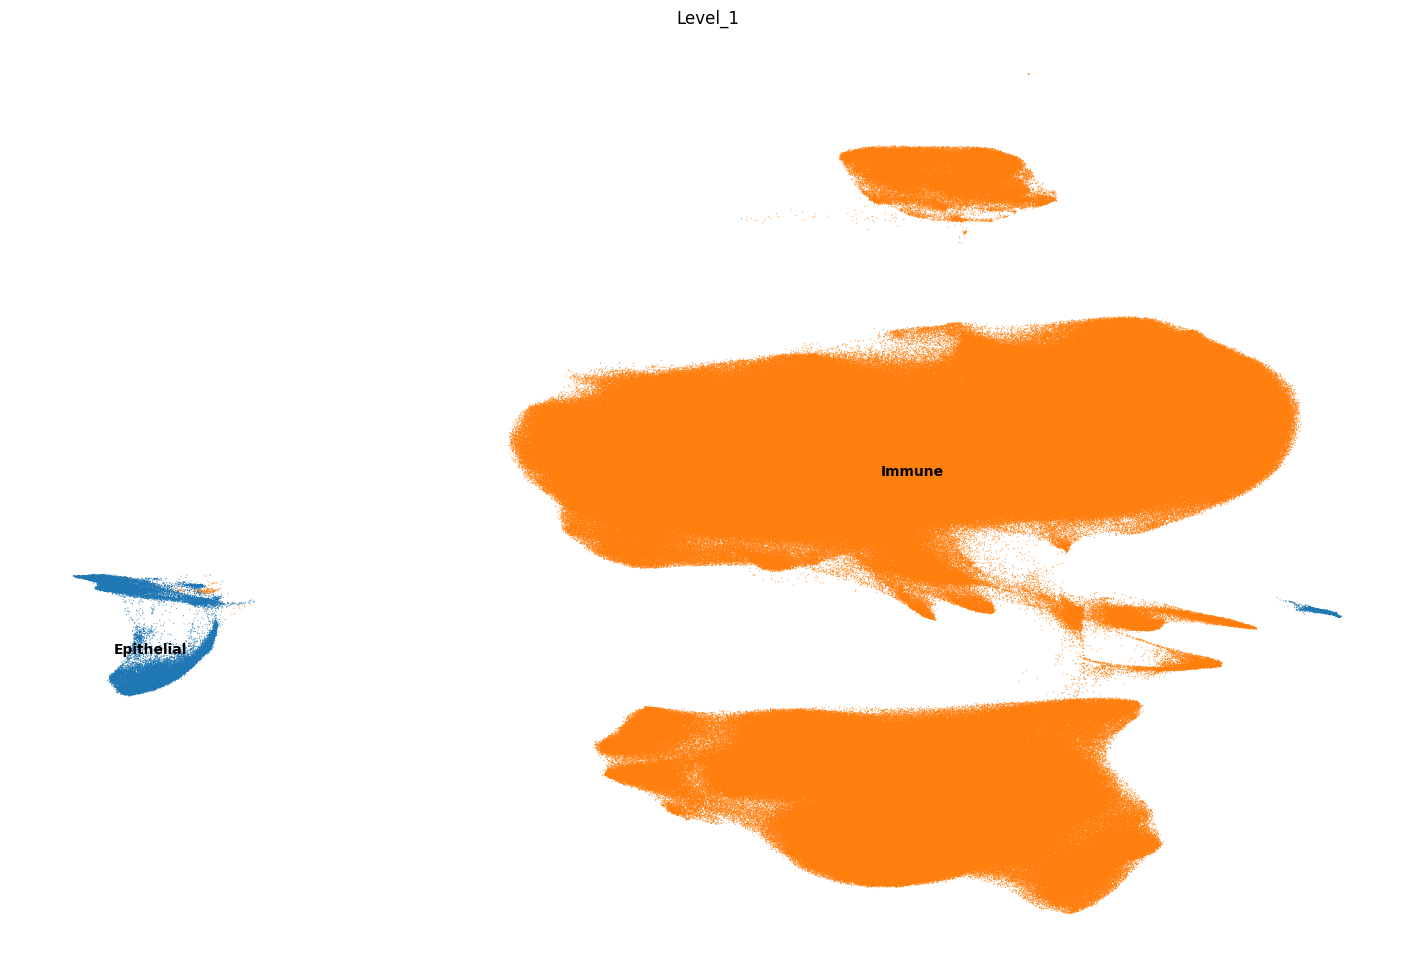

In [38]:
mpl.rcParams["figure.figsize"] = (18, 12)

sc.pl.umap(
    adata,
    color=["Level_1"],
    frameon=False, legend_loc="on data", show=False, size=2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'Level_2'}, xlabel='UMAP1', ylabel='UMAP2'>

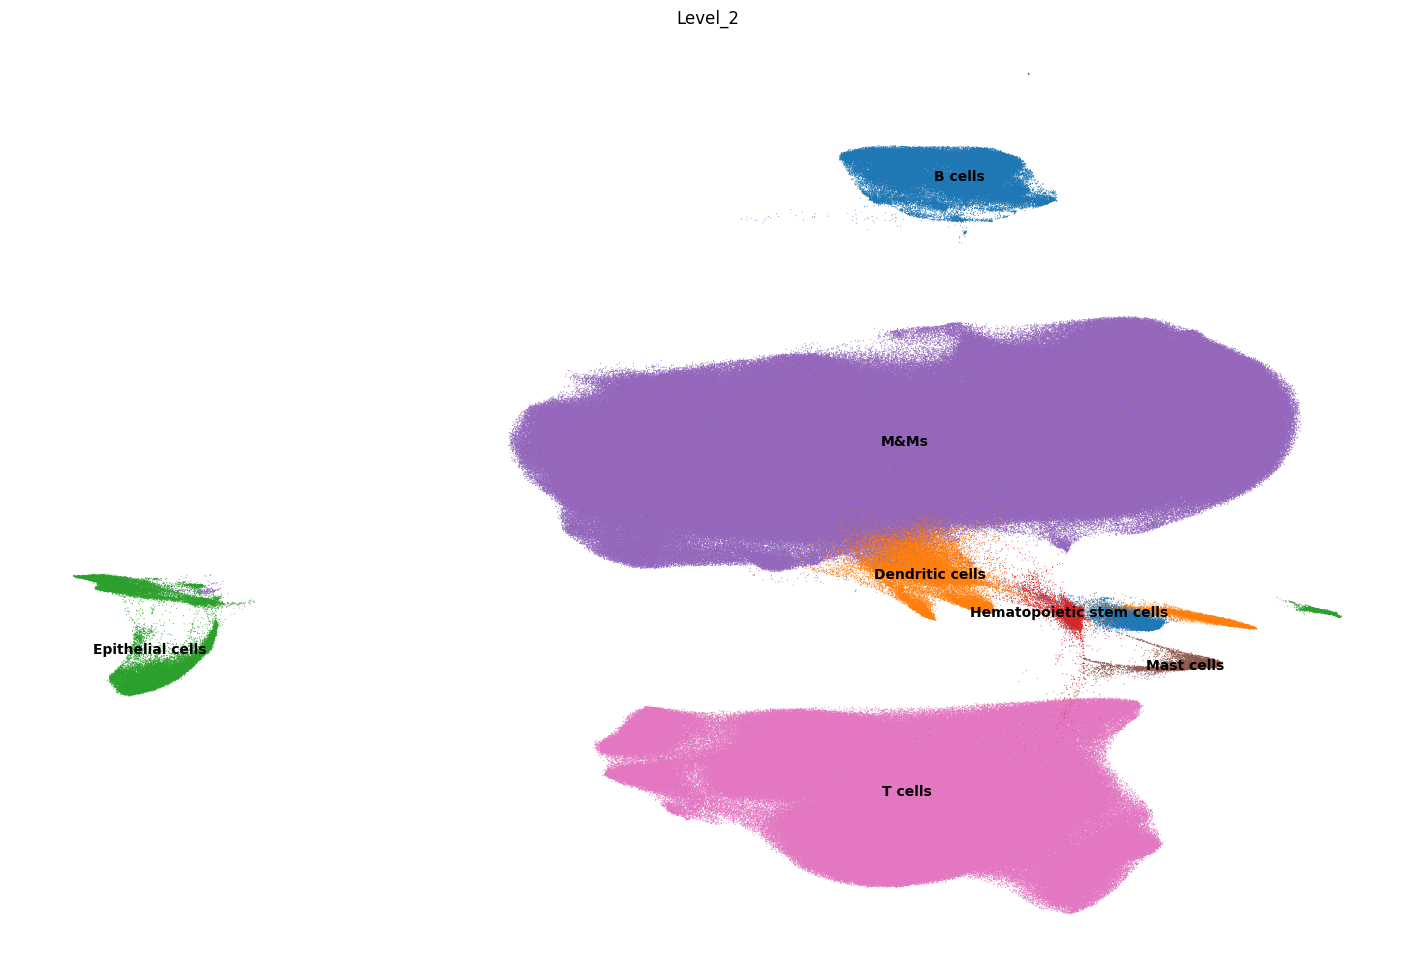

In [39]:
mpl.rcParams["figure.figsize"] = (18, 12)

sc.pl.umap(
    adata,
    color=["Level_2"],
    frameon=False, legend_loc="on data", show=False, size=2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'Level_3'}, xlabel='UMAP1', ylabel='UMAP2'>

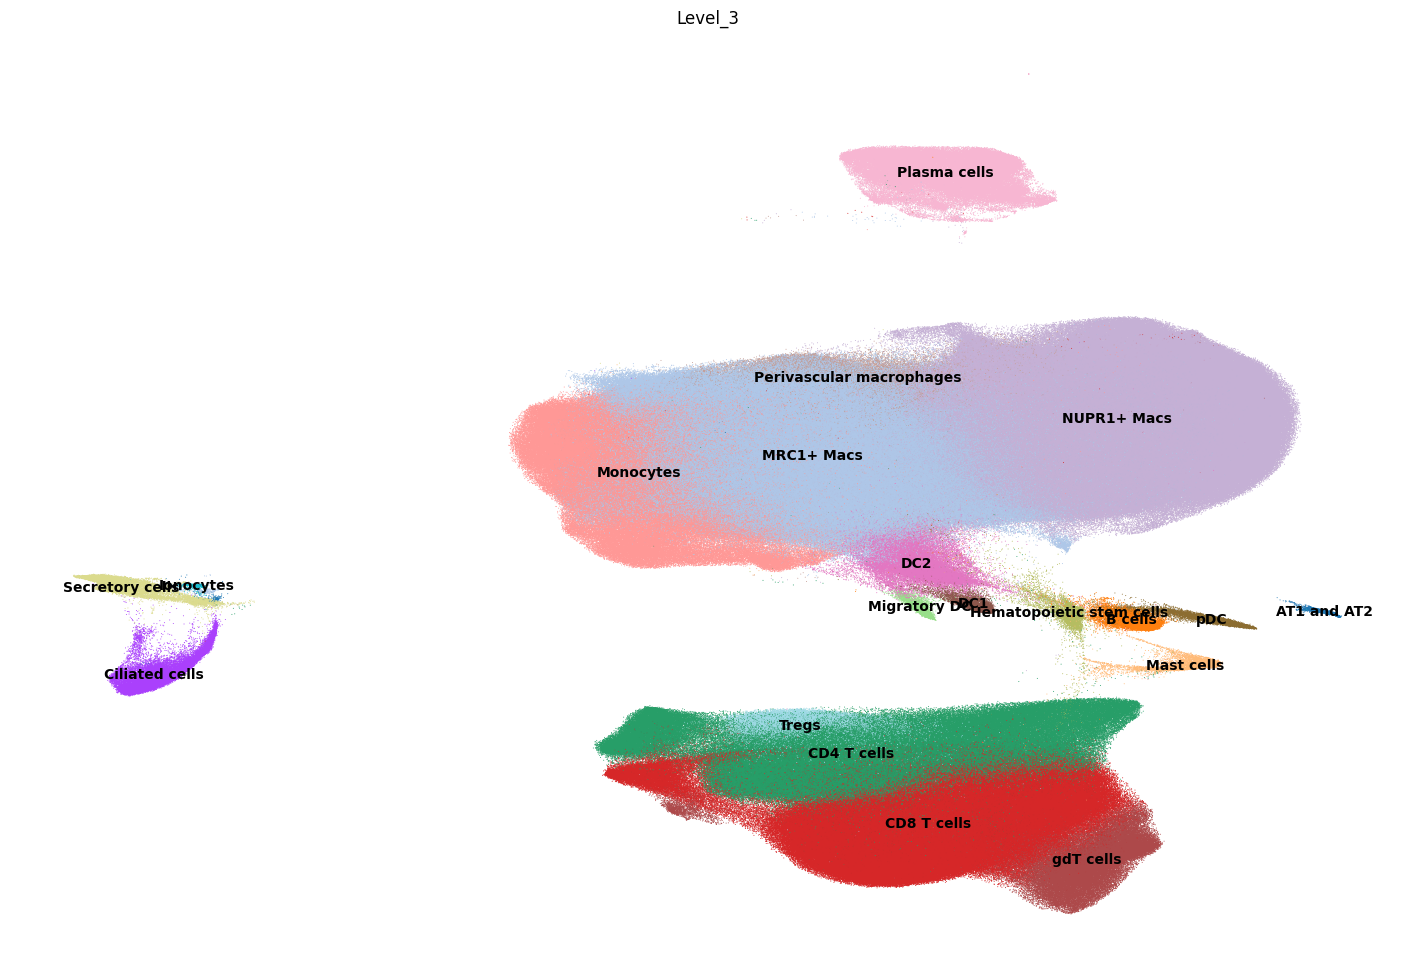

In [40]:
mpl.rcParams["figure.figsize"] = (18, 12)

sc.pl.umap(
    adata,
    color=["Level_3"],
    frameon=False, legend_loc="on data", show=False, size=2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'Level_4'}, xlabel='UMAP1', ylabel='UMAP2'>

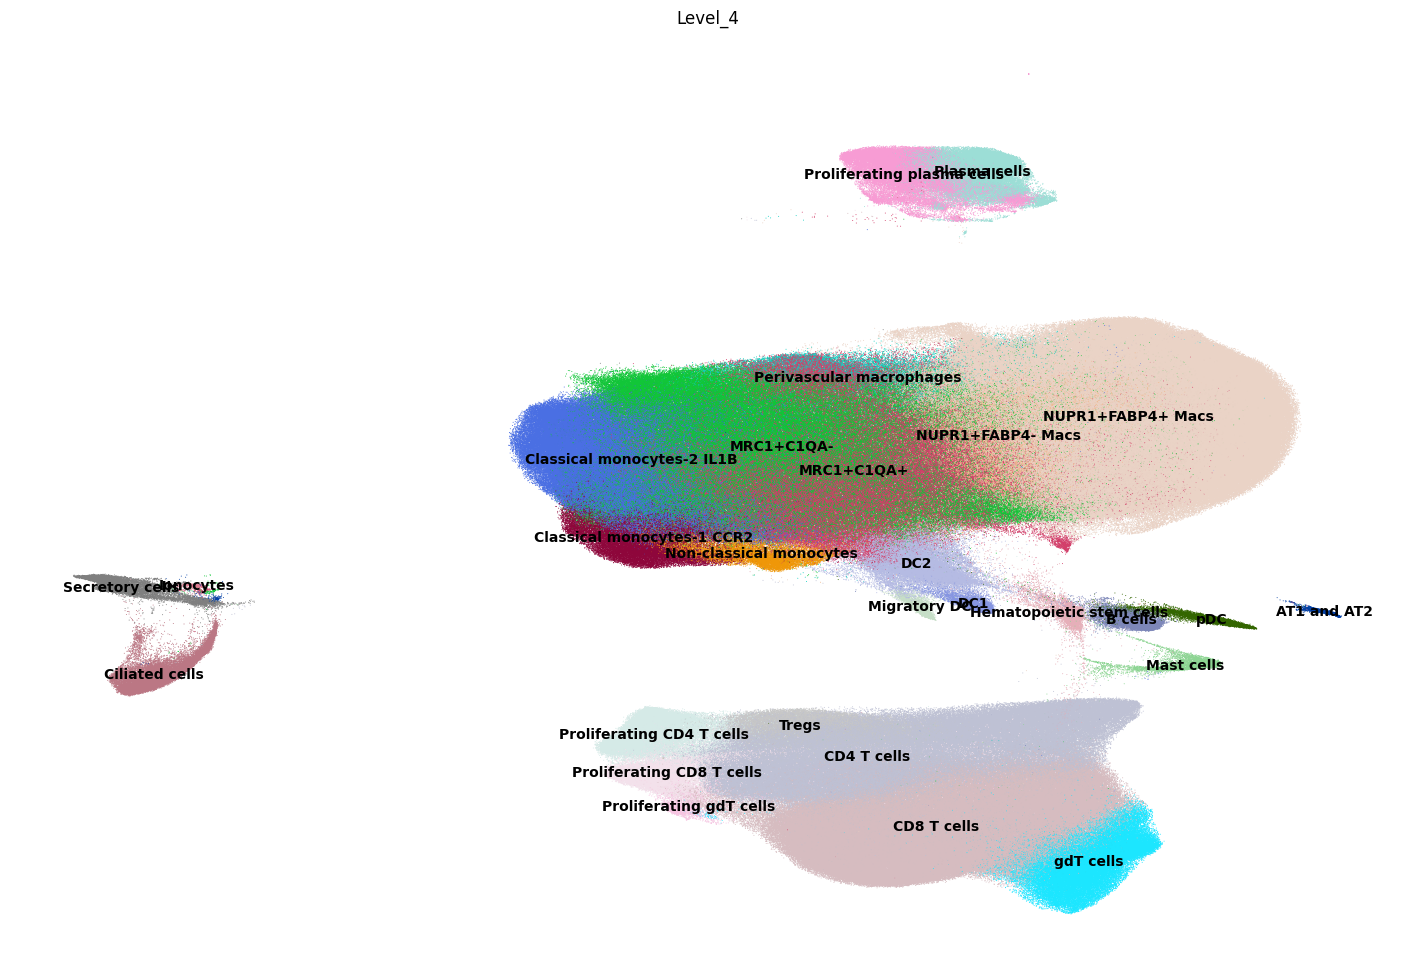

In [41]:
mpl.rcParams["figure.figsize"] = (18, 12)

sc.pl.umap(
    adata,
    color=["Level_4"],
    frameon=False, legend_loc="on data", show=False, size=2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'Level_5'}, xlabel='UMAP1', ylabel='UMAP2'>

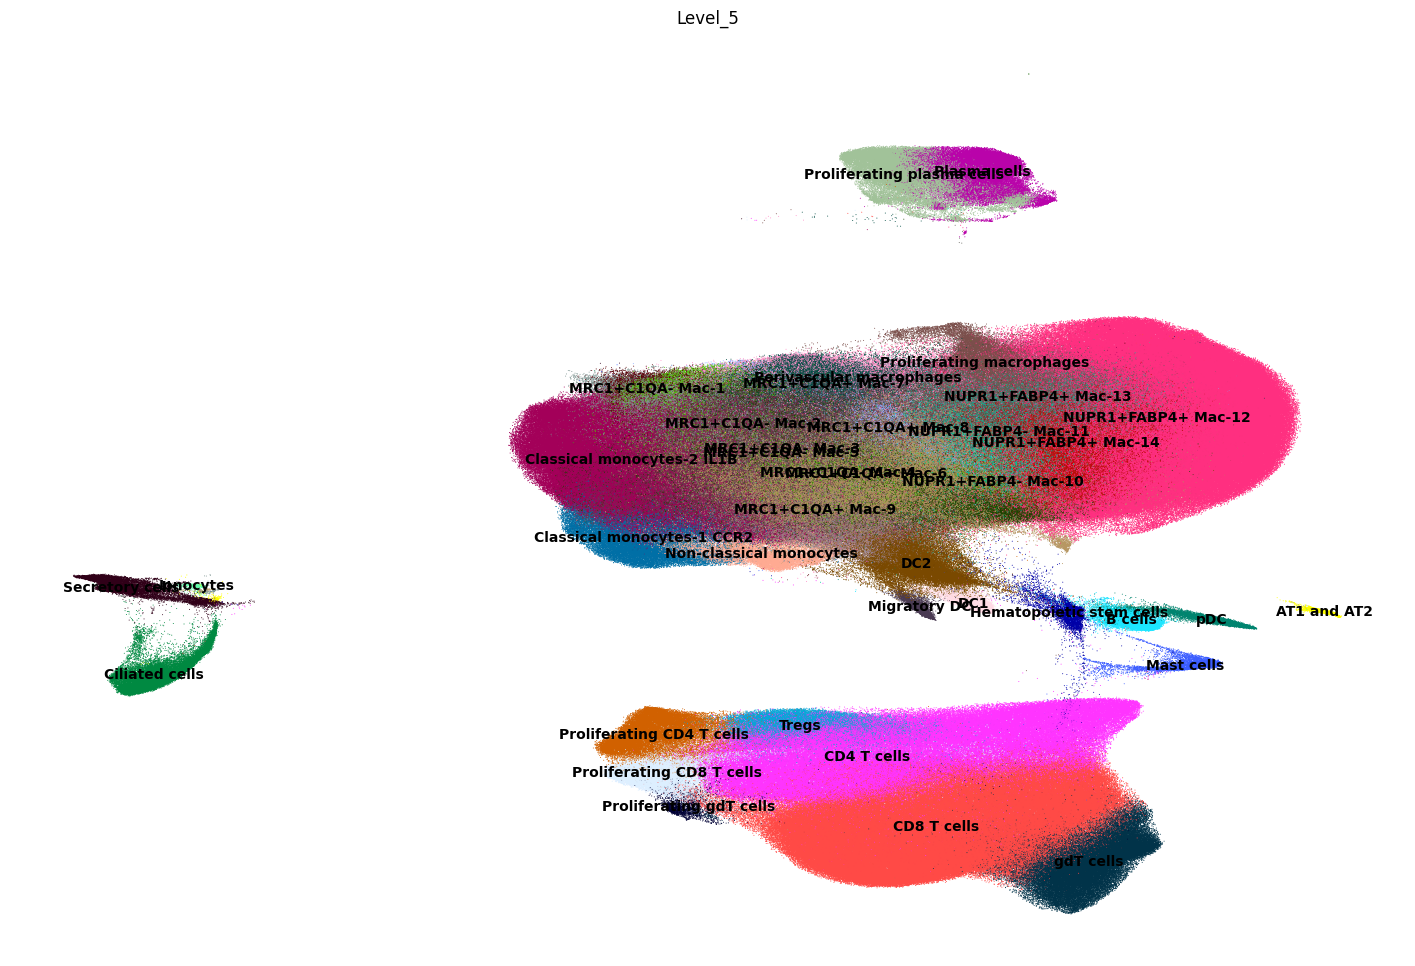

In [42]:
mpl.rcParams["figure.figsize"] = (18, 12)

sc.pl.umap(
    adata,
    color=["Level_5"],
    frameon=False, legend_loc="on data", show=False, size=2)

/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'Level_6'}, xlabel='UMAP1', ylabel='UMAP2'>

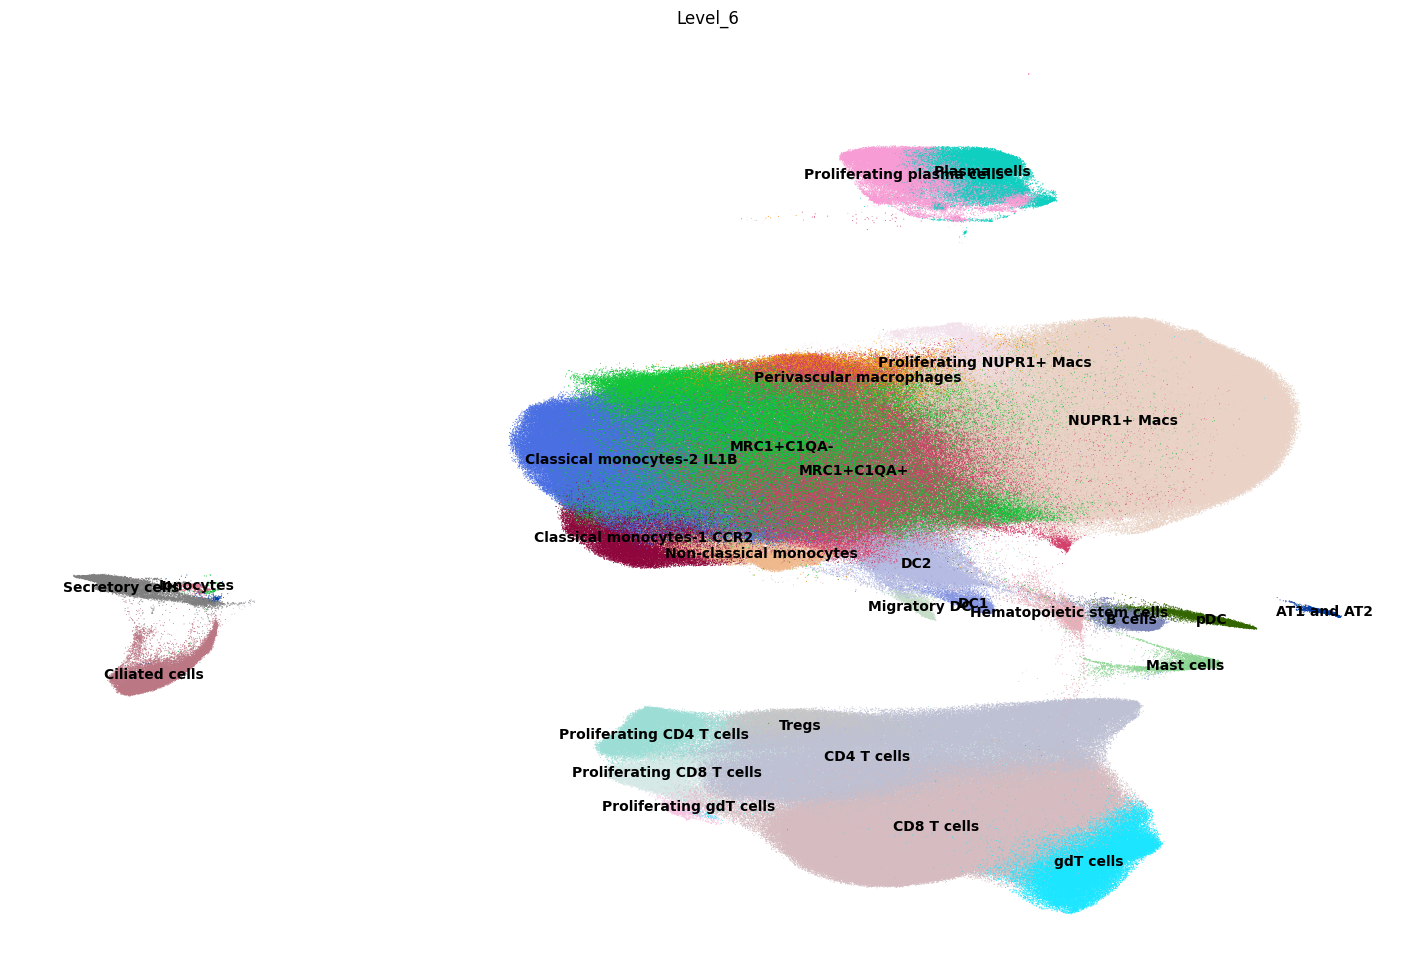

In [43]:
mpl.rcParams["figure.figsize"] = (18, 12)

sc.pl.umap(
    adata,
    color=["Level_6"],
    frameon=False, legend_loc="on data", show=False, size=2)

In [44]:
adata.obs.Level_6.unique().tolist()

['CD4 T cells',
 'CD8 T cells',
 'Mast cells',
 'NUPR1+ Macs',
 'B cells',
 'MRC1+C1QA+',
 'DC2',
 'MRC1+C1QA-',
 'Proliferating CD4 T cells',
 'Proliferating CD8 T cells',
 'Classical monocytes-2 IL1B',
 'Secretory cells',
 'Proliferating NUPR1+ Macs',
 'Tregs',
 'DC1',
 'Ionocytes',
 'Ciliated cells',
 'gdT cells',
 'Migratory DC',
 'Perivascular macrophages',
 'Hematopoietic stem cells',
 'Classical monocytes-1 CCR2',
 'pDC',
 'AT1 and AT2',
 'Proliferating plasma cells',
 'Non-classical monocytes',
 'Plasma cells',
 'Proliferating gdT cells']

### Remove "cell_type" annotations

In [45]:
adata.obs = adata.obs.drop(columns=['cell_type'])

## Generate cluster tree
Pearson correlation plot between clusters using log normalized gene expression data from PCA representation

In [46]:
sc.tl.dendrogram(adata, 'Level_6', cor_method='pearson')

         Falling back to preprocessing with `sc.pp.pca` and default params.


/projects/b1196/envs/serniczek/lib/python3.10/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


<Axes: >

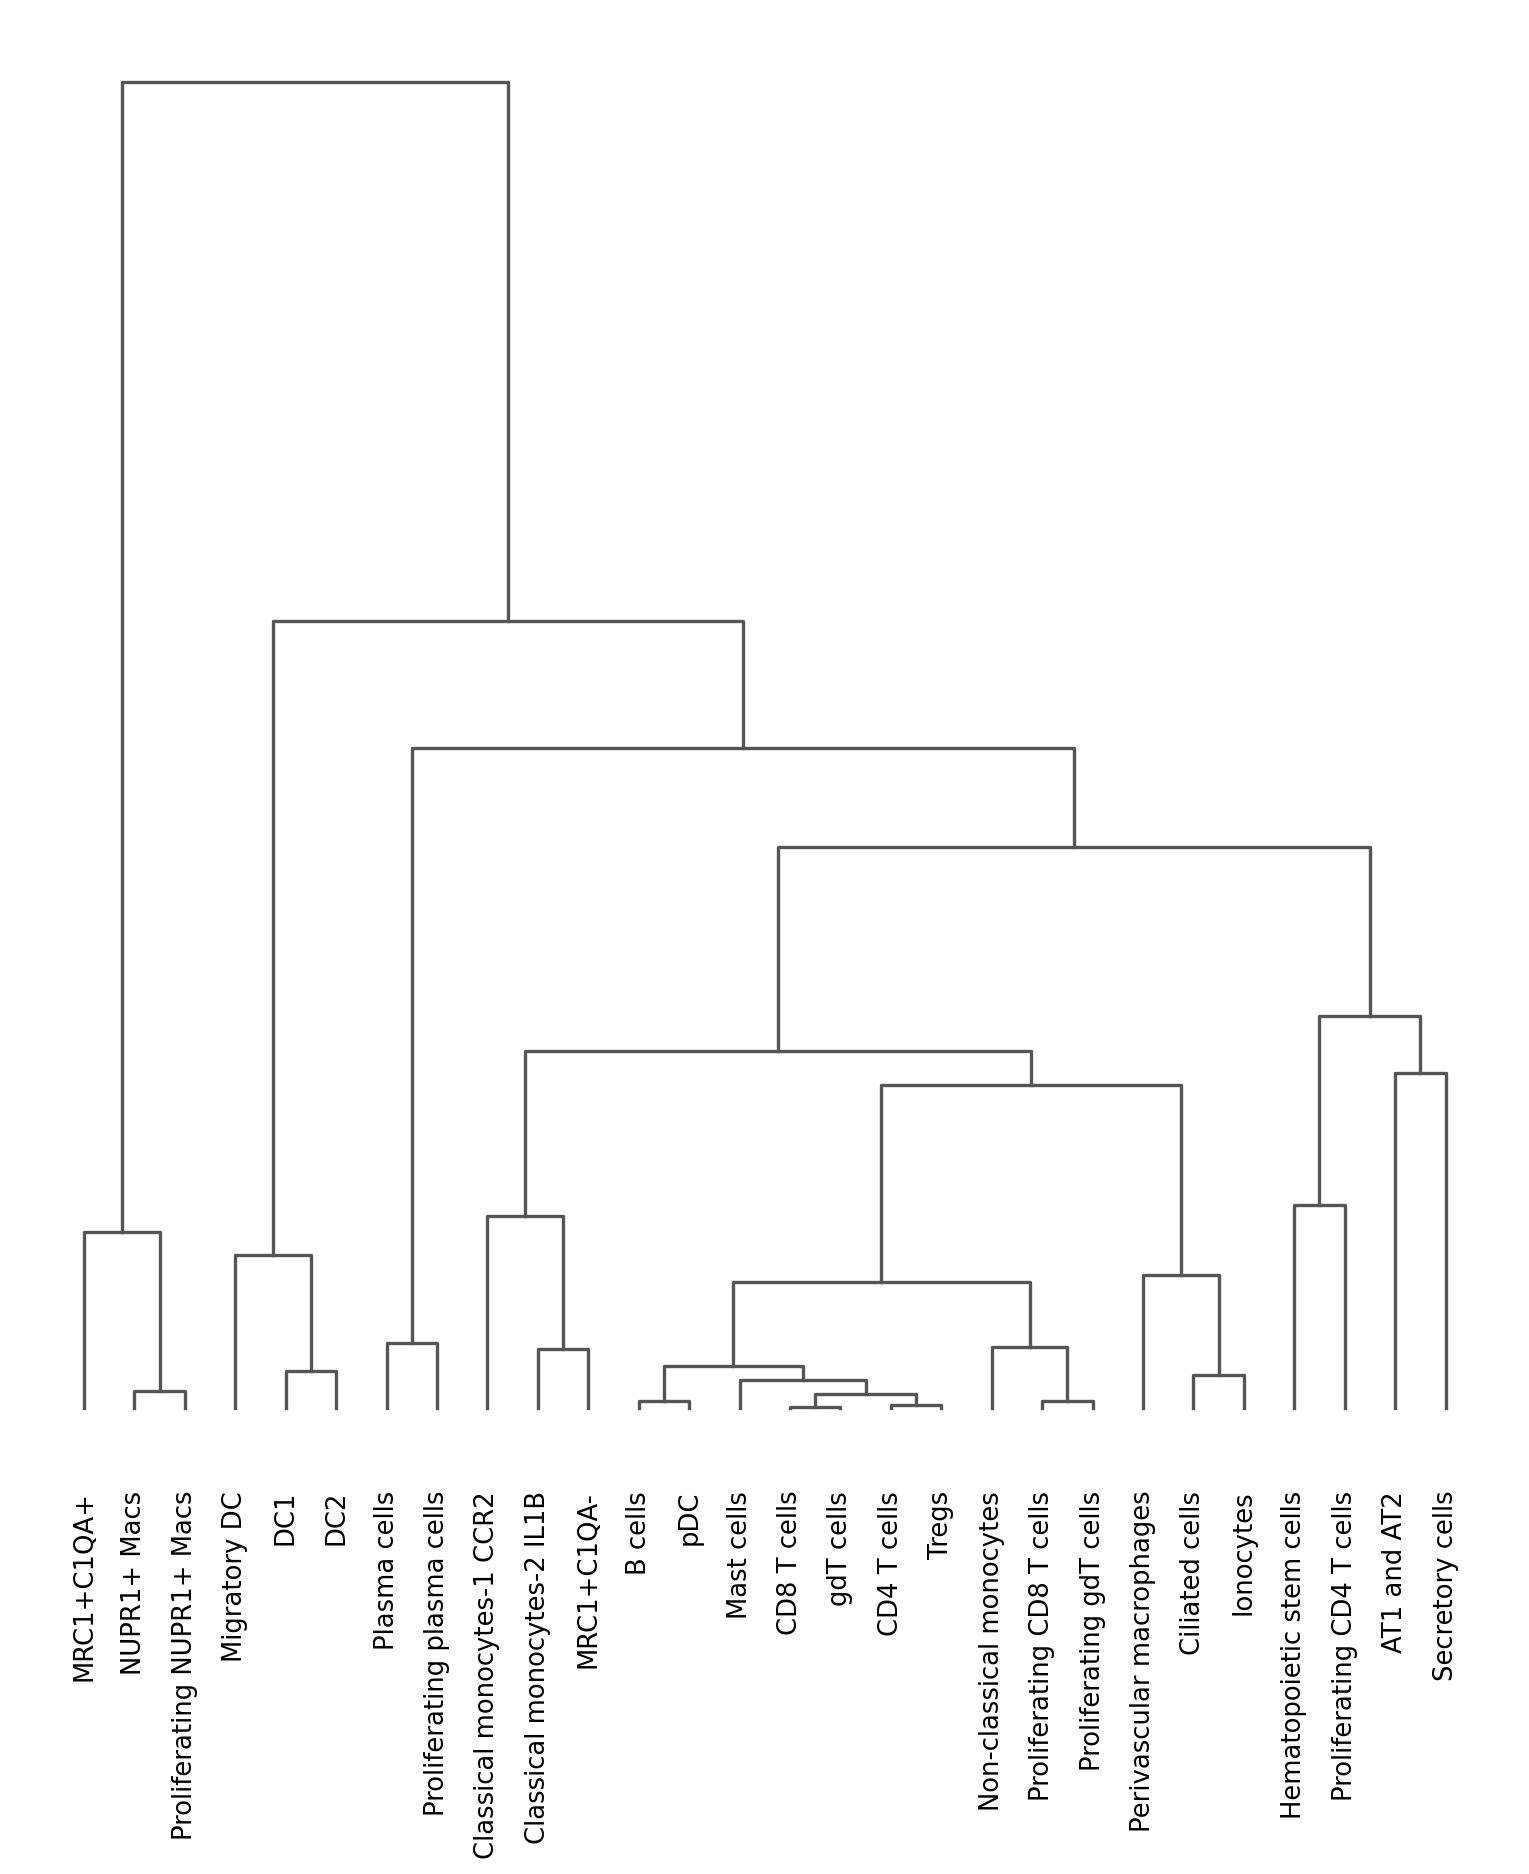

In [47]:
sc.set_figure_params(figsize=(12, 12))
sc.pl.dendrogram(adata, groupby='Level_6', show=False)

## Find markers with t-test

In [50]:
%%time
sc.tl.rank_genes_groups(adata, "Level_6", method="t-test", n_genes=50)

CPU times: user 18min 5s, sys: 13min 45s, total: 31min 50s
Wall time: 31min 51s


/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:398: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/projects/b1196/envs/serniczek/lib/python3.10/site-packages/scanpy/tools/_rank_genes_groups.py:401: PerformanceWarning:

In [51]:
markers = sc_utils.get_markers(adata, "Level_6")

In [52]:
markers.sort_values(["cluster", "avg_logFC"], ascending=[True, False], inplace=True)

## Save

In [ ]:
adata.write(common_data._sc_root / '09_final_full/09_final_full.h5ad')

In [ ]:
adata.obs.to_csv(common_data._sc_root / '09_final_full/09_final_full-metadata.csv')

In [ ]:
markers.to_csv(common_data._sc_root / '09_final_full/09_final_full-markers.csv')

# Start here on reruns

### Load object

In [ ]:
adata = sc.read_h5ad(common_data._sc_root / '09_final_full/09_final_full.h5ad')

# Fix metadata
Add updated metadata from Nick.

### Remove columns from adata that are in meta

In [5]:
meta = pd.read_csv(common_data.SC_LABELS, index_col=0)

In [6]:
columns_to_remove = meta.columns.intersection(adata.obs.columns)

In [7]:
adata.obs.drop(columns=columns_to_remove, inplace=True)

### Merge meta and adata on sample ID

In [8]:
merged = adata.obs.merge(meta, left_on='individual', right_on='bal_barcode', how='left')

In [9]:
merged.bal_barcode.nunique() - meta.bal_barcode.nunique()

0

In [10]:
merged.index = adata.obs_names

In [11]:
adata.obs = merged.copy()

In [12]:
len(adata.obs[adata.obs.perturbation_groups == 'NPC'].individual.unique())

26

In [15]:
meta.shape

(301, 78)

In [17]:
adata.obs.individual.nunique()

301

## Add more metadata

### 1. Demographics: Age, sex, bmi, race

In [18]:
clin_data = pd.read_csv(common_data.CLINICAL, index_col=0)

In [19]:
pasc_meta = pd.read_csv('../data/00_metadata/PASC_deidentified_metadata.csv').set_index('library_id')

In [20]:
auxora_meta = pd.read_csv(
    '../data/00_metadata/auxora.csv',
    names=['patient', 'Age', 'Sex', 'BMI', 'Race']
).set_index('patient')

In [21]:
ssc_meta = pd.read_csv(
    '../data/00_metadata/ssc.csv',
    names=['patient', 'Age', 'Sex', 'BMI', 'Race']
).set_index('patient')

In [22]:
duke_meta = pd.read_csv('../data/00_metadata/duke_ozone_controls.csv').set_index('Library ID')

In [23]:
script_meta = clin_data.dropna(subset='bal_barcode').set_index('bal_barcode')

In [24]:
script_meta.rename(columns={'Gender': 'Sex'}, inplace=True)

In [25]:
sample_idx = adata.obs.individual.isin(script_meta.index)
for col in ('Sex', 'Age', 'BMI', 'Race'):
    adata.obs.loc[sample_idx, col] = script_meta[col][adata.obs.individual[sample_idx]].values

In [26]:
sample_idx = adata.obs.library_id.isin(pasc_meta.index)
for col in ('Sex', 'Age', 'BMI', 'Race'):
    adata.obs.loc[sample_idx, col] = pasc_meta[col][adata.obs.library_id[sample_idx]].values

In [27]:
sample_idx = adata.obs.patient.isin(auxora_meta.index)
for col in ('Sex', 'Age', 'BMI', 'Race'):
    adata.obs.loc[sample_idx, col] = auxora_meta[col][adata.obs.patient[sample_idx]].values

In [28]:
sample_idx = adata.obs.patient.isin(ssc_meta.index)
for col in ('Sex', 'Age', 'BMI', 'Race'):
    adata.obs.loc[sample_idx, col] = ssc_meta[col][adata.obs.patient[sample_idx]].values

In [29]:
sample_idx = adata.obs.library_id.isin(duke_meta.index)
for col in ('Sex', 'Age', 'BMI', 'Race'):
    adata.obs.loc[sample_idx, col] = duke_meta[col][adata.obs.library_id[sample_idx]].values

In [30]:
adata.obs.Race.replace({
    'Black': 'Black or African American',
    'Asian Indian': 'Asian',
    'Other': 'Unknown or Not Reported'
}, inplace=True)

In [31]:
adata.obs.Sex.replace({
    'male': 'Male',
    'female': 'Female',
    'F': 'Female',
    'M': 'Male'
}, inplace=True)

## Deal with NAs
https://github.com/scverse/anndata/issues/679

In [47]:
num_columns = [
    'ICU_stay', 'ICU_day', 'SOFA_score', 'Immunocompromised_flag', 'External_transfer_flag',
    'Binary_outcome', 'day_of_hospitalization', 'week_of_hospitalization', 'number_of_pathogens',
    'episode_counter', 'number_of_episodes', 'number_of_total_pathogens',
    'day_since_first_intubation', 'days_on_ventilator', 'Age', 'BMI', 'sequencing_depth',
    'sequencing_saturation', 'frac_reads_in_cells', 'viability'
]
for col in num_columns:
    adata.obs[col].fillna(-1, inplace=True)

In [ ]:
adata.obs.drop(columns=[
    'test_split_pg2_split_1', 'test_split_pg2_split_2',
    'test_split_pg2_split_3', 'test_split_pg2_split_4',
    'viral_vs_bacterial_test_split_1', 'viral_vs_bacterial_test_split_2',
    'viral_vs_bacterial_test_split_3', 'viral_vs_bacterial_test_split_4',
    'vap_outcome_test_split_1', 'vap_outcome_test_split_2',
    'vap_outcome_test_split_3', 'vap_outcome_test_split_4',
    'vap_onset_emp_test_split_1', 'vap_onset_emp_test_split_2',
    'vap_onset_emp_test_split_3', 'vap_onset_emp_test_split_4',
], inplace=True)

In [49]:
adata.obs.drop(columns=[
    'test_split_1', 'test_split_2', 'test_split_3', 'test_split_4',
], inplace=True)

In [50]:
adata.obs.drop(columns=[
    'RASS_score_binned', 'GCS_verbal_response_binned', 'GCS_motor_response_binned', 'GCS_eye_opening_binned',
    'GSC_score', 'Driving_pressure', 'Procalcitonin_ff', 'D_dimer_ff', 'LDH_ff',
    'Cumulative_vent_changes', 'days_of_icu_abx_until_today', 'cumulative_icu_steroid_dose_until_today',
    'mean_nat_score_until_yesterday'
], inplace=True)

In [51]:
adata.obs.apply(lambda x: x.isna().sum())

name                                   0
library_id                             0
individual                             0
protocol                               0
n_genes_by_counts                      0
total_counts                           0
pct_counts_in_top_10_genes             0
pct_counts_in_top_20_genes             0
total_counts_mito                      0
pct_counts_mito                        0
total_counts_ribo                      0
pct_counts_ribo                        0
n_counts                               0
_scvi_batch                            0
_scvi_labels                           0
viral_pathogen                         0
future_vap_onset                       0
vap_onset                              0
Level_1                                0
Level_2                                0
Level_3                                0
Level_4                                0
Level_5                                0
Level_6                                0
Patient_id      

In [52]:
adata.obs.loc[adata.obs.Patient_id.isna(), 'Patient_id'] = adata.obs.individual[adata.obs.Patient_id.isna()]
adata.obs.Episode_id.fillna('none', inplace=True)
adata.obs.Discharge_disposition.fillna('NA', inplace=True)
adata.obs.Episode_etiology.fillna('NA', inplace=True)
adata.obs.Episode_NPC_other_infection.fillna('NA', inplace=True)
adata.obs.pathogen_groups.fillna('NA', inplace=True)
adata.obs.episode_type.fillna('NA', inplace=True)
adata.obs.clinical_opinion_l2.fillna('NA', inplace=True)

adata.obs.future_episode_outcome.fillna('not-relevant', inplace=True)
adata.obs.total_pathogens.fillna('NA', inplace=True)
adata.obs.prev_episode_type.fillna('NA', inplace=True)
adata.obs.prev_episode_id.fillna('none', inplace=True)
adata.obs.first_episode_type.fillna('NA', inplace=True)
adata.obs.first_pathogen.fillna('NA', inplace=True)
adata.obs.prev_pathogen_groups.fillna('NA', inplace=True)

adata.obs.is_npc_with_fungi.fillna(False, inplace=True)
adata.obs.is_npc_control.fillna(False, inplace=True)
adata.obs.is_culture_negative_pneumonia.fillna(False, inplace=True)

In [53]:
bool_columns = [
    'clear_cut', 'is_episode_cured', 'vap_onset',
    'neutrophils'
]
for col in bool_columns:
    adata.obs[col] = adata.obs[col].astype(float).fillna(-1).astype(int)

In [54]:
idx = adata.obs.number_of_bals.isna()
bals_per_pt = adata.obs.loc[idx].groupby('patient').individual.nunique()
adata.obs.loc[idx, 'number_of_bals'] = bals_per_pt[adata.obs.patient[idx]].values

In [55]:
adata.obs.is_healthy_control = adata.obs.is_healthy_control.astype(bool)
adata.obs.is_npc_with_fungi = adata.obs.is_npc_with_fungi.astype(bool)
adata.obs.is_npc_control = adata.obs.is_npc_control.astype(bool)
adata.obs.is_culture_negative_pneumonia = adata.obs.is_culture_negative_pneumonia.astype(bool)
adata.obs.is_long_covid = adata.obs.is_long_covid.astype(bool)

In [56]:
adata.obs.apply(lambda x: x.isna().sum())

name                             0
library_id                       0
individual                       0
protocol                         0
n_genes_by_counts                0
total_counts                     0
pct_counts_in_top_10_genes       0
pct_counts_in_top_20_genes       0
total_counts_mito                0
pct_counts_mito                  0
total_counts_ribo                0
pct_counts_ribo                  0
n_counts                         0
_scvi_batch                      0
_scvi_labels                     0
viral_pathogen                   0
future_vap_onset                 0
vap_onset                        0
Level_1                          0
Level_2                          0
Level_3                          0
Level_4                          0
Level_5                          0
Level_6                          0
Patient_id                       0
ICU_stay                         0
ICU_day                          0
Episode_id                       0
bal_barcode         

### Add Sex determined by gene expression

In [57]:
genes_mean = []
genes_loc = adata.raw.var_names.isin(['XIST', 'USP9Y'])
for s in adata.obs.individual.unique():
    genes_mean.append(
        [s] + adata.raw.X[adata.obs.individual.eq(s)][:, genes_loc].mean(axis=0).A1.tolist()
    )

In [58]:
genes_mean = pd.DataFrame(genes_mean, columns=['sample'] + adata.raw.var_names[genes_loc].tolist())

Text(0, 0.5, 'USP9Y')

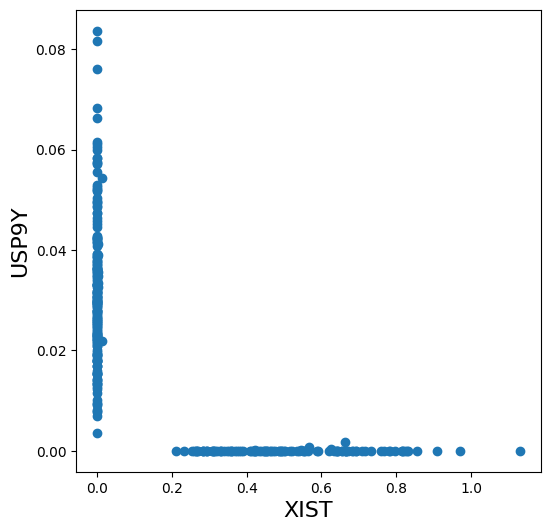

In [59]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(genes_mean.XIST, genes_mean.USP9Y);
ax.set_xlabel('XIST', size=16)
ax.set_ylabel('USP9Y', size=16)

In [60]:
genes_mean['Sex'] = genes_mean.XIST.gt(0.1).replace({
    True: 'Female',
    False: 'Male'
})

In [61]:
genes_mean = genes_mean.set_index('sample')

In [62]:
adata.obs['Sex_genes'] = genes_mean.Sex[adata.obs.individual].values

In [66]:
adata.obs.Age = adata.obs.Age.astype(int)

In [67]:
adata.obs.BMI = adata.obs.BMI.astype(float)

In [68]:
adata.obs.Patient_id = adata.obs.Patient_id.astype(str).str.replace(r'\.0$', '', regex=True)

In [69]:
adata.obs.Level_6 = adata.obs.Level_6.cat.rename_categories({
    'Perivascular macrophages': 'Interstitial macrophages',
})

## Save

In [ ]:
adata.write(common_data._sc_root / '09_final_full-1/09_final_full-1.h5ad')

In [ ]:
adata.obs.to_csv(common_data._sc_root / '09_final_full-1/09_final_full-1-metadata.csv')

In [72]:
adata.shape

(2438672, 1000)

In [ ]:
# markers.to_csv(common_data._sc_root / '09_final_full-1/09_final_full-1-markers.csv')

## Downsample

In [74]:
downsampled = adata.obs.sample(frac=0.1, random_state=1066).index

In [75]:
downsampled = adata[downsampled].copy()

In [76]:
downsampled.var.drop(columns='gene_ids', inplace=True)

In [77]:
downsampled.raw.var.drop(columns='gene_ids', inplace=True)

### Save

In [ ]:
downsampled.write_h5ad(common_data._sc_root / '09_downsampled/09_downsampled.h5ad')

In [ ]:
downsampled.obs.to_csv(common_data._sc_root / '09_downsampled/09_downsampled-metadata.csv')